The following note is my rough understanding of how DMRG works:
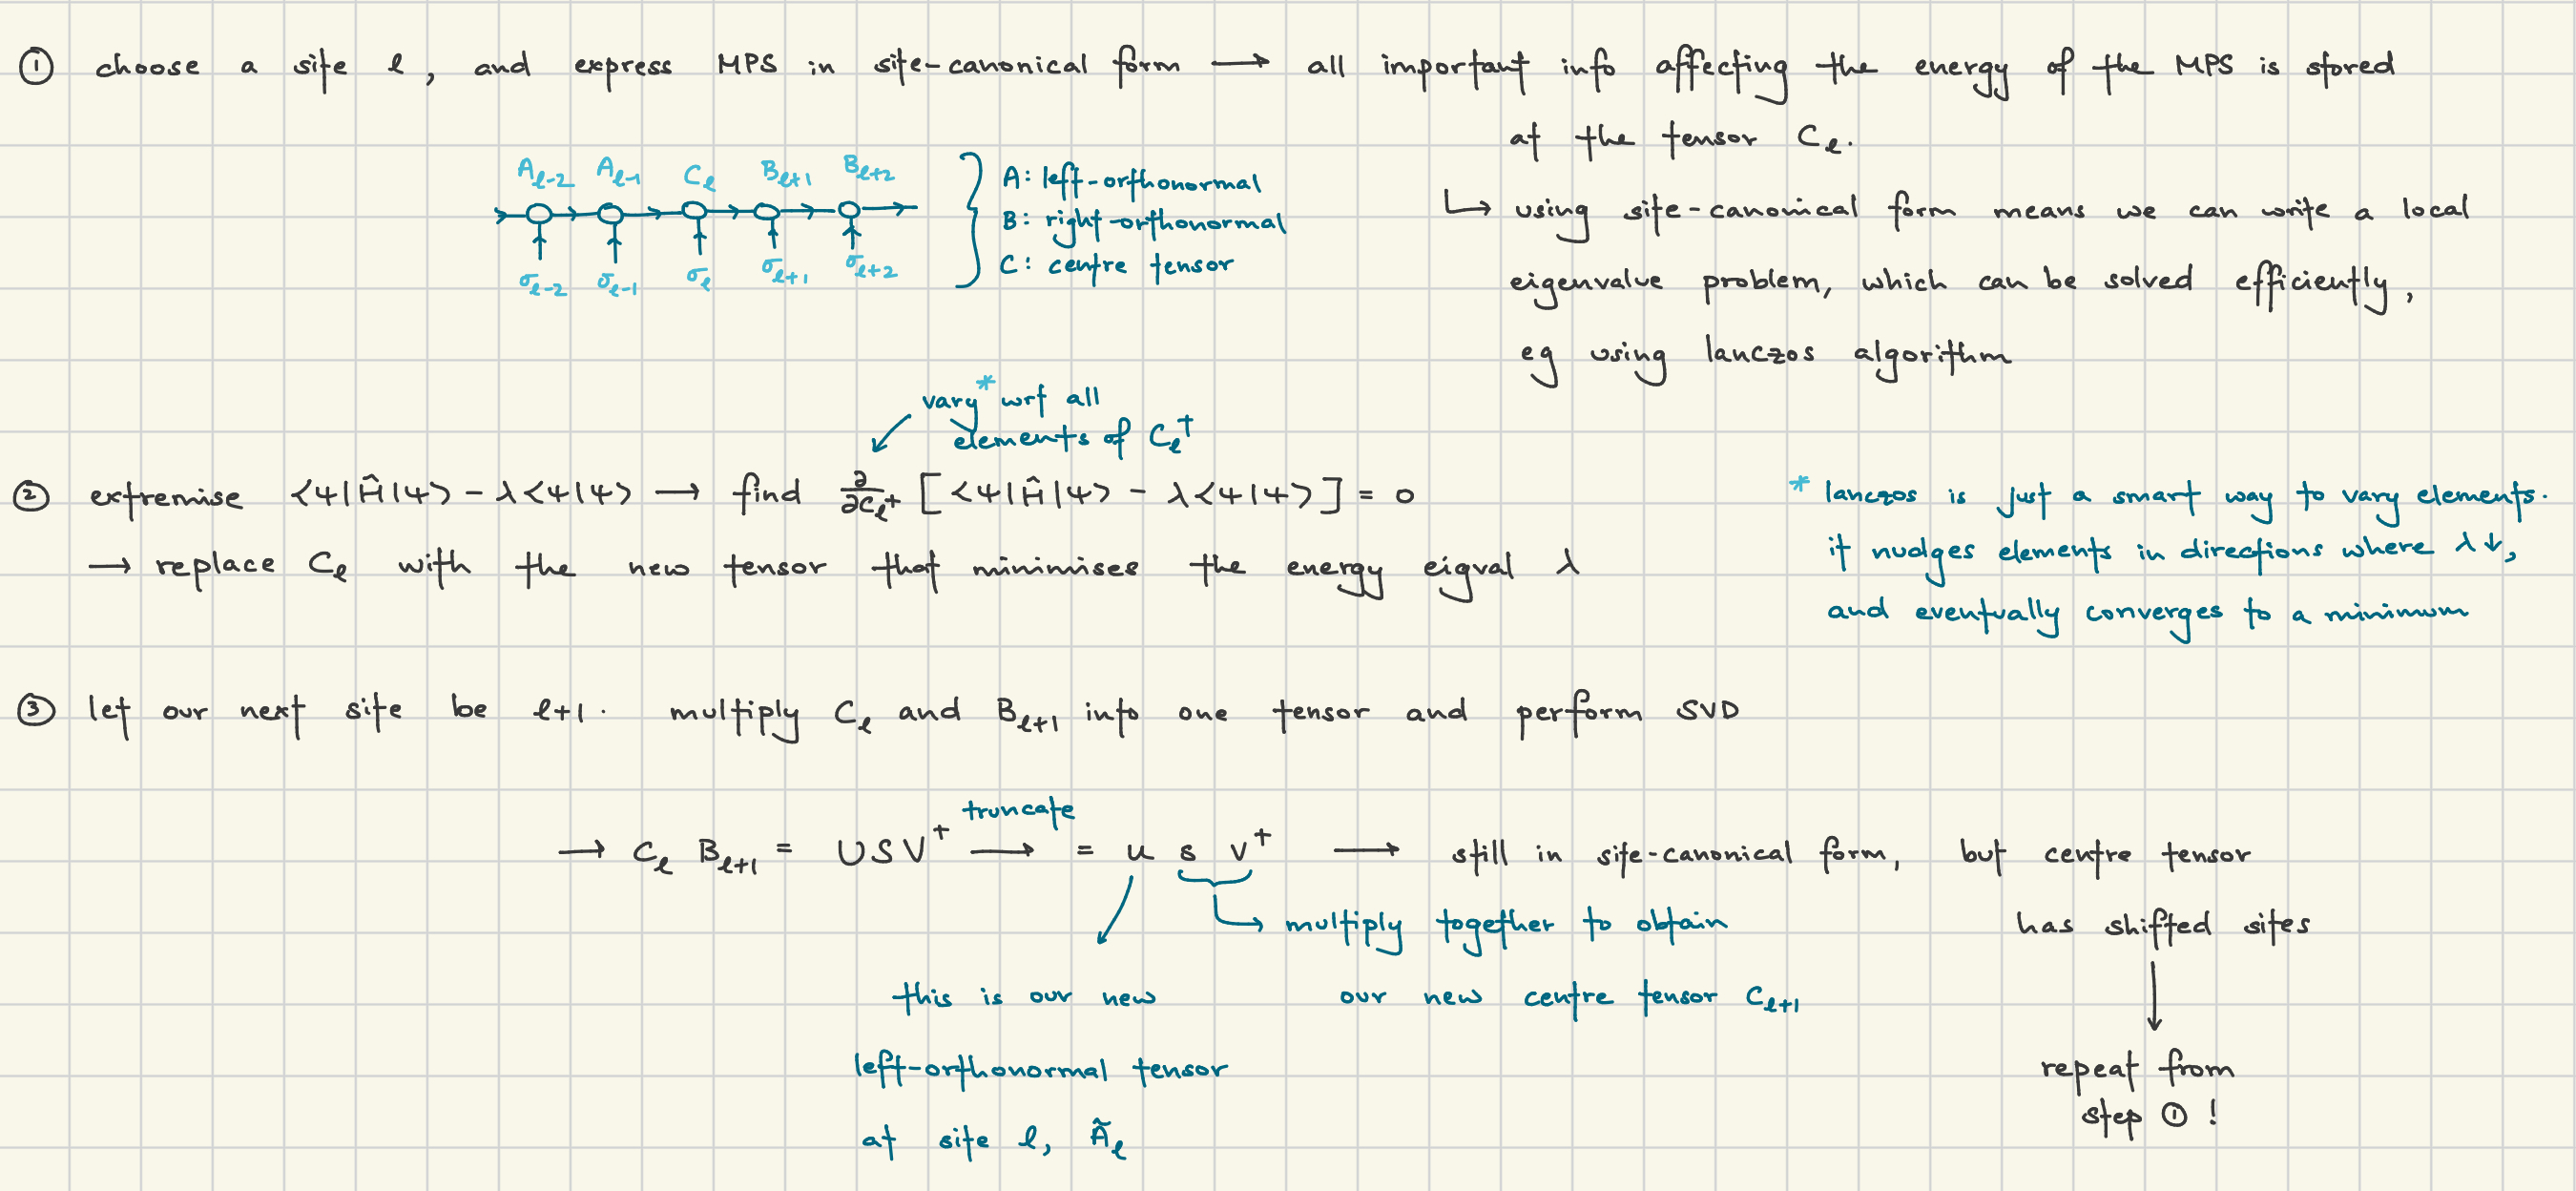

In [13]:
import tenpy

Here, we will use MPS and DMRG to variationally find the ground state of the 1D Ising Model, which is given by
$$
\hat H = -J\sum^{L-1}_{i=1}\hat Z_i\hat Z_{i+1}-h\sum^L_{i=1}\hat X.
$$
TeNPY's built-in transverse-field Ising chain model class, `TFIChain`, uses
$$
\hat H = -J\sum^{L-1}_{i=1}\hat X_i\hat X_{i+1}-g\sum^L_{i=1}\hat Z,
$$
which is identical up to a global basis rotation.

In [14]:
from tenpy.models.tf_ising import TFIChain

# adjust model parameters here

L = 15
J = 1.0
g = 1.4

model_params = dict(
    L = L,
    J = J,
    g = g,
    bc_MPS = 'finite',
    conserve = None
)

model = TFIChain(model_params)
# automatically builds an MPO representation of the Hamiltonian
# according to the inputs in the model_params dictionary.

DMRG essentially sweeps through the MPS, adding entanglement (ie increasing bond dimension) only when it contributes to a decrease in energy. Hence, we ideally start with a product state so that DMRG adds entanglement only when needed.

On that note, we initialise our ground state guess to $\ket\Psi=\ket{\uparrow}^{\otimes L}$, through we could have made it all $\ket\downarrow$ too.

In [15]:
from tenpy.networks.mps import MPS

product_state = ["up"] * L      # generate initial state. can do ["down"] * L too.
psi = MPS.from_product_state(
    model.lat.mps_sites(),
    product_state,              # convert product_state to an MPS
    bc='finite',                # open boundary conditions (ie not periodic)
    unit_cell_width=1           # lattice is a 1D chain
)

In [16]:
from tenpy.algorithms import dmrg

dmrg_params = dict(
    mixer=True,         # adds some controlled randomness to escape bad minima, converge reliably
    max_sweeps=10,      # at most 10 back-and-forth passes
    max_E_err=1e-10,    # stop when energy change between sweeps is this small
    trunc_params=dict(  # how to truncate when performing SVD and changing sites
        chi_max=100,    # maximum allowed bond dimension, ie loosely, maximum allowed entanglement
        svd_min=1e-10   # truncate singular values (diag values in S matrix) below this value
    ),
)

info = dmrg.run(psi, model, dmrg_params) # run DMRG
E0 = info['E']

print("Ground state energy:", E0)

Ground state energy: -23.577015207676162


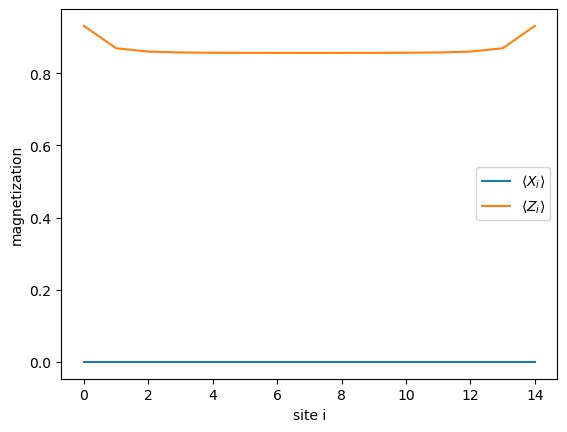

In [17]:
mz = [psi.expectation_value("Sigmaz", i) for i in range(L)]
mx = [psi.expectation_value("Sigmax", i) for i in range(L)]

import matplotlib.pyplot as plt

plt.plot(mx, label=r'$\langle X_i \rangle$')
plt.plot(mz, label=r'$\langle Z_i \rangle$')
plt.xlabel('site i')
plt.ylabel('magnetization')
plt.legend()
plt.show()

In [18]:
print("Bond dimensions are:")
psi.chi

Bond dimensions are:


[2, 4, 8, 14, 17, 20, 20, 20, 20, 17, 14, 8, 4, 2]